# Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

# Load Dataset

In [5]:
df=pd.read_csv("Unemployment in India.csv")

In [7]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


# Check Dataset 

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [12]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [14]:
df.shape

(768, 7)

In [16]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

# Check Missing Values

In [19]:
df.isna().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

## Remove missing

In [22]:
df = df.dropna()

# Rename columns name

In [25]:
df.columns = [
    "State",
    "Date",
    "Frequency",
    "Unemployment_Rate",
    "Employed",
    "Labour_Participation_Rate",
    "Region"
]

# Convert Date Column

In [28]:
df["Date"] = pd.to_datetime(df["Date"])

C:\Users\HP\AppData\Local\Temp\ipykernel_9052\936118274.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


# Basic Analysis

In [31]:
# average unemployment
print(df["Unemployment_Rate"].mean())

11.787945945945946


In [33]:
#Maximum unemployment
print(df["Unemployment_Rate"].max())

76.74


In [35]:
#Minimum unemployment
print(df["Unemployment_Rate"].min())

0.0


# Line Chart

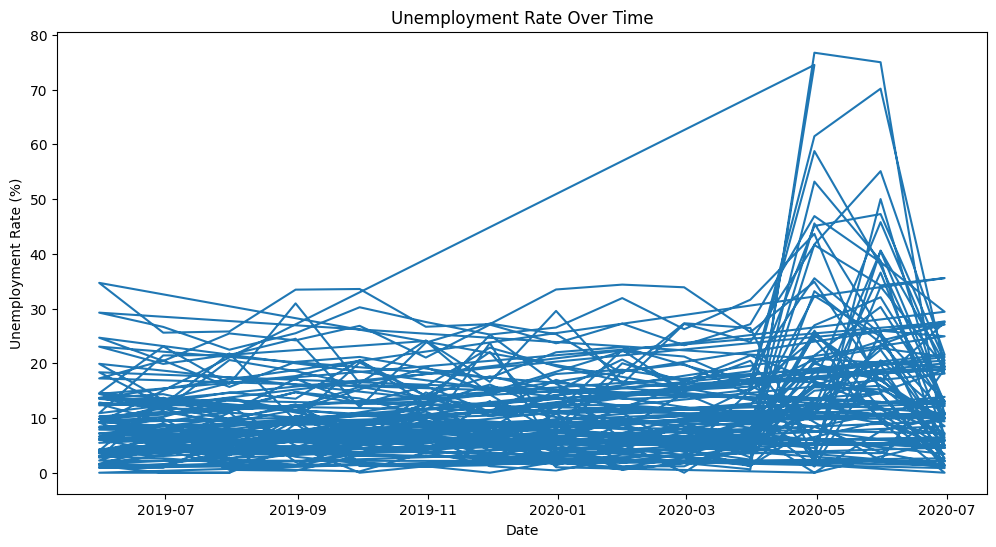

In [38]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Unemployment_Rate"])

plt.title("Unemployment Rate Over Time")

plt.xlabel("Date")

plt.ylabel("Unemployment Rate (%)")

plt.show()

# State-wise Analysis

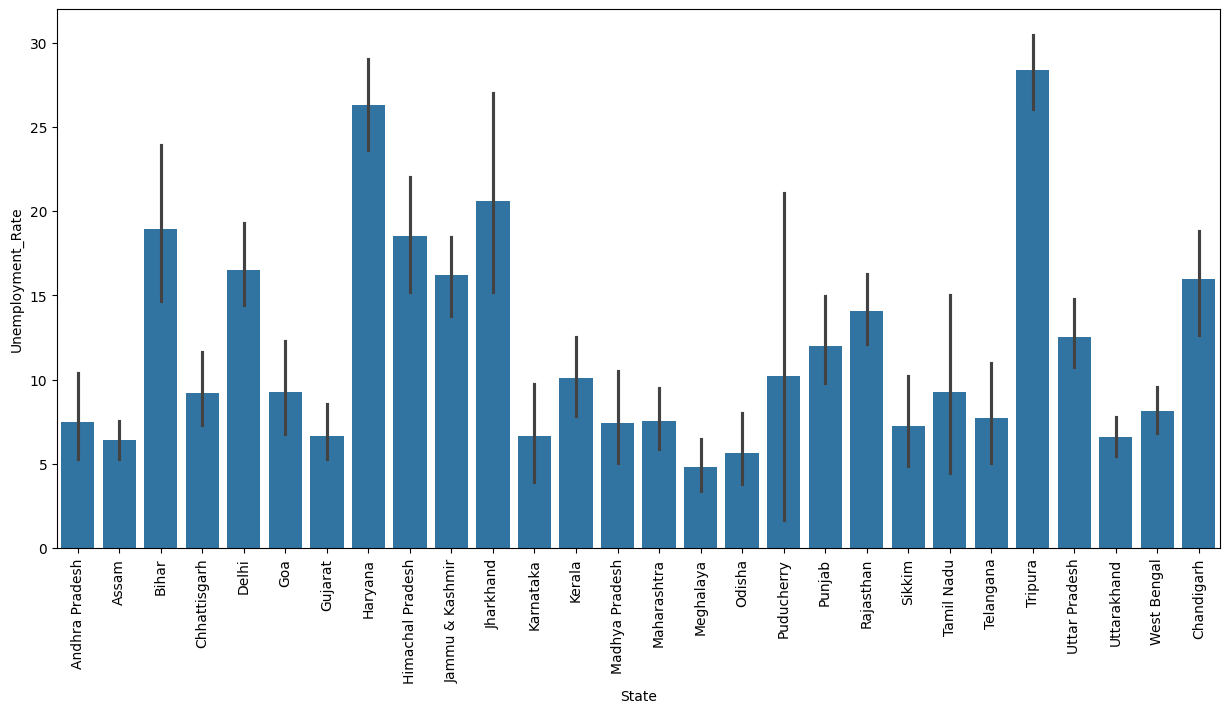

In [41]:
plt.figure(figsize=(15,7))

sns.barplot(
    x="State",
    y="Unemployment_Rate",
    data=df
)

plt.xticks(rotation=90)

plt.show()

# Covid-19 Analysis
    -Separate data before and after lockdown

In [45]:
covid = df[df["Date"] >= "2020-03-01"]

covid.head()

,State,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Region
10,Andhra Pradesh,2020-03-31,Monthly,4.06,11359660.0,40.66,Rural
11,Andhra Pradesh,2020-04-30,Monthly,16.29,8792827.0,36.03,Rural
12,Andhra Pradesh,2020-05-31,Monthly,14.46,9526902.0,38.16,Rural
13,Andhra Pradesh,2020-06-30,Monthly,0.85,15572975.0,53.76,Rural
23,Assam,2020-03-31,Monthly,3.77,9878742.0,47.05,Rural


In [49]:
#Average unemployment during Covid
covid["Unemployment_Rate"].mean()

17.774362745098042

# Covid Visualization

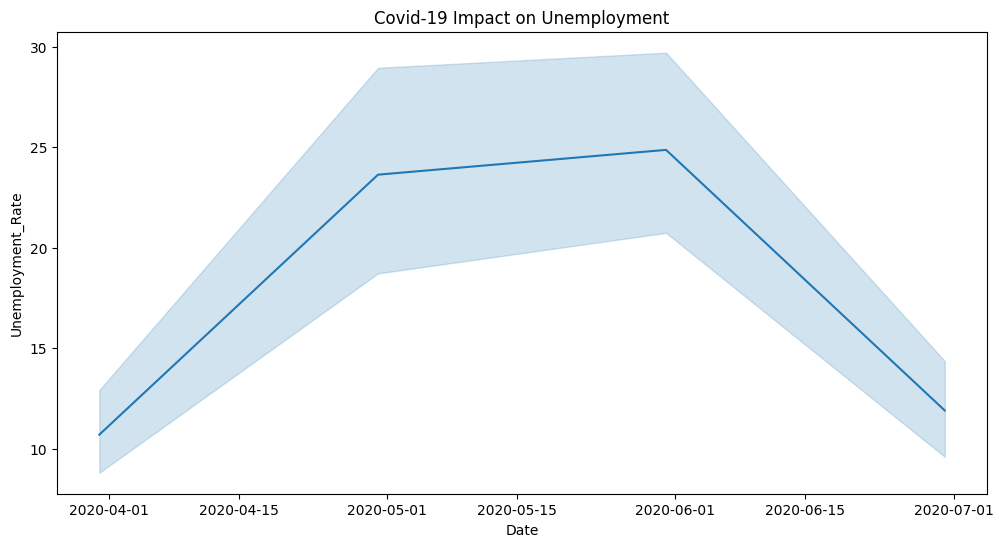

In [52]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x="Date",
    y="Unemployment_Rate",
    data=covid
)

plt.title("Covid-19 Impact on Unemployment")

plt.show()

# Heatmap

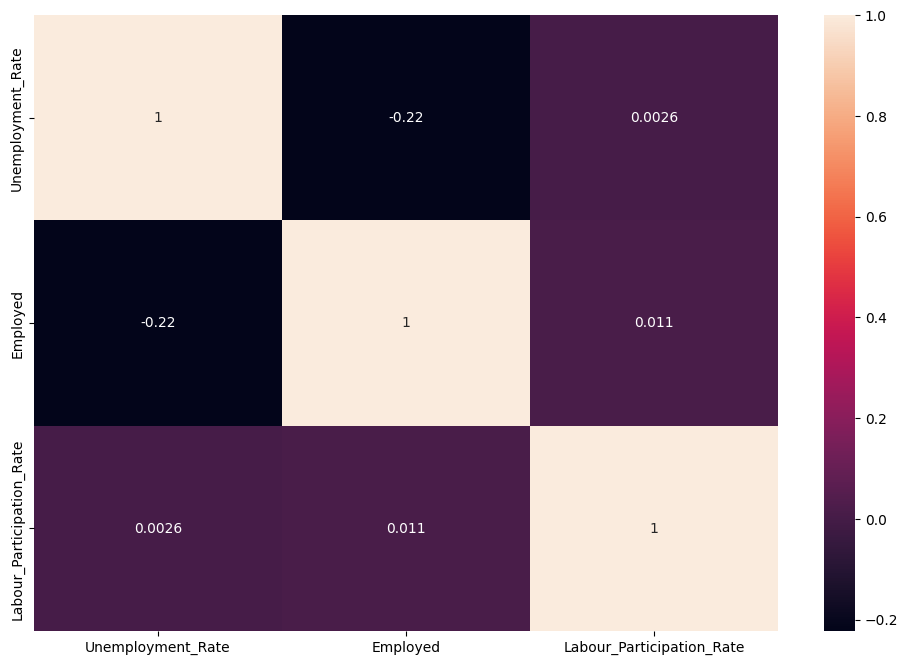

In [55]:
plt.figure(figsize=(12,8))

corr = df[
    [
        "Unemployment_Rate",
        "Employed",
        "Labour_Participation_Rate"
    ]
].corr()

sns.heatmap(corr, annot=True)

plt.show()

# Boxplot

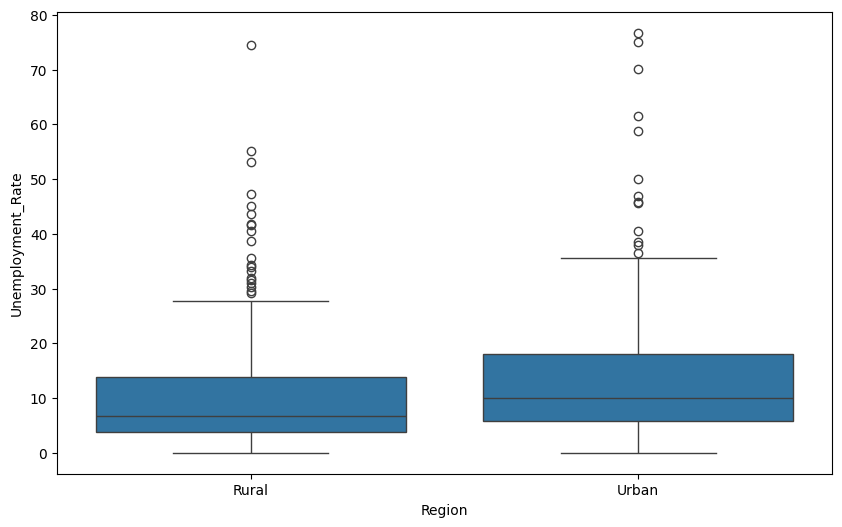

In [58]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Region",
    y="Unemployment_Rate",
    data=df
)

plt.show()